In [1]:
 
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 


In [2]:
# Set paths for the data
base_dir = r"C:\Users\FPTSHOP\OneDrive\Máy tính\data_violence_img\new_violence"
violent_dir = os.path.join(base_dir, 'violence')
nonviolent_dir = os.path.join(base_dir, 'non_violence')

In [3]:
# 1. Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

In [4]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 9413 images belonging to 2 classes.


In [6]:
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1660 images belonging to 2 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 11073 images belonging to 2 classes.


In [8]:
from sklearn.utils import class_weight

class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = {i: class_weights_array[i] for i in range(2)}

# MobileNetV2

In [9]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, regularizers

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

inputs = layers.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# Callbacks 
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

In [11]:
# Train
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks
)


d:\OU\graduation-project\smart-social-network\ai-service\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 56s 180ms/step - accuracy: 0.6175 - loss: 0.8510 - val_accuracy: 0.8331 - val_loss: 0.3907 - learning_rate: 1.0000e-04
Epoch 2/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 67s 227ms/step - accuracy: 0.7964 - loss: 0.4900 - val_accuracy: 0.8416 - val_loss: 0.3804 - learning_rate: 1.0000e-04
Epoch 3/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 70s 236ms/step - accuracy: 0.8128 - loss: 0.4506 - val_accuracy: 0.8524 - val_loss: 0.3590 - learning_rate: 1.0000e-04
Epoch 4/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 56s 190ms/step - accuracy: 0.8287 - loss: 0.4124 - val_accuracy: 0.8428 - val_loss: 0.3612 - learning_rate: 1.0000e-04
Epoch 5/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 59s 200ms/step - accuracy: 0.8425 - loss: 0.3865 - val_accuracy: 0.8645 - val_loss: 0.3523 - learning_rate: 1.0000e-04
Epoch 6/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 67s 227ms/step - accuracy: 0.8417 - loss: 0.3881 - val_accuracy: 0.8518 - val_loss: 0.3540 - learning_rate: 1.0000e-04
Epoch 7/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 60s 20

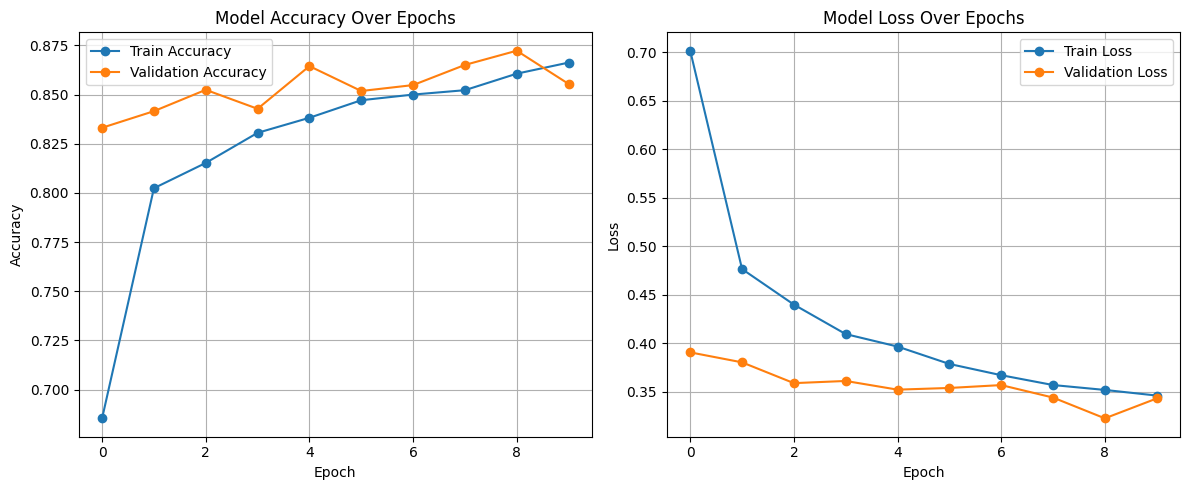

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Accuracy Plot
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Model Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Model Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


In [13]:
# Save the model
model.save(r"D:\OU\graduation-project\smart-social-network\ai-service\app\data\models\model.h5")


In [14]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)

# Print Test Accuracy as a percentage with 3 decimal places
print(f"Test Accuracy: {test_accuracy * 100:.3f}")


d:\OU\graduation-project\smart-social-network\ai-service\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


347/347 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.9398 - loss: 0.1768
Test Accuracy: 90.373


#  MobileNetV2_Fine_tune

In [15]:
# Fine-tune top 30% of base model
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [16]:
print("Fine-tuning model...")
model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    callbacks=callbacks
)

Fine-tuning model...
Epoch 1/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 80s 245ms/step - accuracy: 0.8121 - loss: 0.4556 - val_accuracy: 0.7404 - val_loss: 0.7805 - learning_rate: 1.0000e-05
Epoch 2/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 68s 230ms/step - accuracy: 0.8417 - loss: 0.3870 - val_accuracy: 0.7620 - val_loss: 0.7529 - learning_rate: 1.0000e-05
Epoch 3/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 67s 228ms/step - accuracy: 0.8688 - loss: 0.3583 - val_accuracy: 0.7922 - val_loss: 0.5864 - learning_rate: 1.0000e-05
Epoch 4/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 69s 234ms/step - accuracy: 0.8758 - loss: 0.3280 - val_accuracy: 0.7873 - val_loss: 0.6217 - learning_rate: 1.0000e-05
Epoch 5/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 70s 239ms/step - accuracy: 0.8886 - loss: 0.3030 - val_accuracy: 0.8187 - val_loss: 0.5332 - learning_rate: 1.0000e-05


In [17]:
model.save(r"D:\OU\graduation-project\smart-social-network\ai-service\app\data\models\mobileNet_finetune.h5")

In [18]:
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1] * 100:.3f}%")

Final Validation Accuracy: 85.542%


# ResNet50

In [19]:
from tensorflow.keras.applications import ResNet50 

# Step 1: Set up base model
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model_resnet.trainable = False  # Freeze for initial training

# Step 2: Add custom layers on top
inputs = layers.Input(shape=(128, 128, 3))
x = base_model_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # Binary output

model_resnet = models.Model(inputs, outputs)

In [20]:
# Compile
model_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [21]:
# 3. Training with Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
]

In [22]:
# Training
print("Training ResNet50...")
history_resnet = model_resnet.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    class_weight=class_weights,
    callbacks=callbacks
)

Training ResNet50...
Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 120s 393ms/step - accuracy: 0.6003 - loss: 0.6923 - val_accuracy: 0.5037 - val_loss: 0.7372 - learning_rate: 0.0010
Epoch 2/10
  1/294 ━━━━━━━━━━━━━━━━━━━━ 1:31 311ms/step - accuracy: 0.5000 - loss: 0.7490

d:\OU\graduation-project\smart-social-network\ai-service\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


294/294 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.5000 - loss: 0.7490 - val_accuracy: 0.5049 - val_loss: 0.7456 - learning_rate: 0.0010
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 114s 386ms/step - accuracy: 0.6375 - loss: 0.6435 - val_accuracy: 0.5496 - val_loss: 0.6883 - learning_rate: 0.0010
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.5312 - loss: 0.6681 - val_accuracy: 0.5882 - val_loss: 0.6465 - learning_rate: 0.0010
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 116s 395ms/step - accuracy: 0.6468 - loss: 0.6258 - val_accuracy: 0.6183 - val_loss: 0.6569 - learning_rate: 0.0010
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.6562 - loss: 0.6430 - val_accuracy: 0.6176 - val_loss: 0.6519 - learning_rate: 0.0010
Epoch 7/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 115s 392ms/step - accuracy: 0.6513 - loss: 0.6237 - val_accuracy: 0.5270 - val_loss: 1.4912 - learning_rate: 0.0010
Epoch 8/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7500 - loss: 

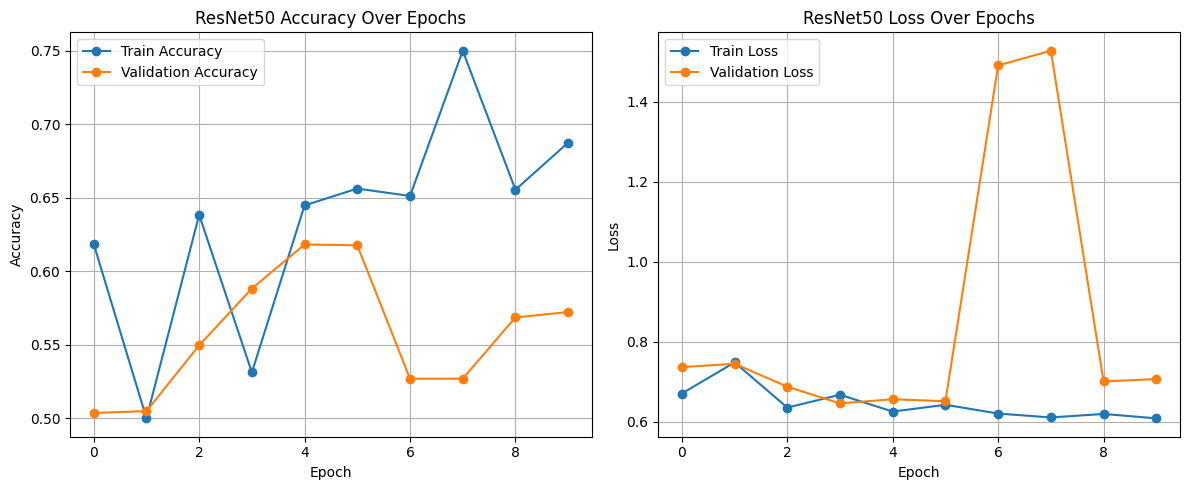

In [23]:
import matplotlib.pyplot as plt

def plot_resnet_history(history):
    # Accuracy Plot
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('ResNet50 Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('ResNet50 Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
plot_resnet_history(history_resnet)


# Fine-tuning ResNet50...

In [24]:
# Step 6: Unfreeze and fine-tune
print("Fine-tuning ResNet50...")
base_model_resnet.trainable = True

model_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # smaller LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Fine-tuning ResNet50...


In [25]:
history_finetune = model_resnet.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.6483 - loss: 0.7149 - val_accuracy: 0.5235 - val_loss: 1.2590 - learning_rate: 1.0000e-05
Epoch 2/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 466s 2s/step - accuracy: 0.8480 - loss: 0.3430 - val_accuracy: 0.6488 - val_loss: 0.6269 - learning_rate: 1.0000e-05
Epoch 3/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.8865 - loss: 0.2750 - val_accuracy: 0.7946 - val_loss: 0.4564 - learning_rate: 1.0000e-05
Epoch 4/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.9103 - loss: 0.2173 - val_accuracy: 0.8681 - val_loss: 0.3619 - learning_rate: 1.0000e-05
Epoch 5/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.9317 - loss: 0.1797 - val_accuracy: 0.8867 - val_loss: 0.3317 - learning_rate: 1.0000e-05
Epoch 6/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 462s 2s/step - accuracy: 0.9353 - loss: 0.1654 - val_accuracy: 0.8958 - val_loss: 0.3243 - learning_rate: 1.0000e-05
Epoch 7/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - acc

In [26]:

def evaluate_model(model, generator, name):
    test_loss, test_accuracy = model.evaluate(generator)
    print(f"{name} Test Accuracy: {test_accuracy*100:.4f}")
    
    y_pred = model.predict(generator)
    y_pred_classes = (y_pred > 0.5).astype(int)
    y_true = generator.classes[:len(y_pred_classes)]
    
    print(f"\nClassification Report for {name}:\n", classification_report(y_true, y_pred_classes))
    
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

347/347 ━━━━━━━━━━━━━━━━━━━━ 108s 312ms/step - accuracy: 0.9753 - loss: 0.0822
Fine-tuned ResNet50 Test Accuracy: 96.5773
347/347 ━━━━━━━━━━━━━━━━━━━━ 110s 314ms/step

Classification Report for Fine-tuned ResNet50:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      5231
           1       0.99      0.94      0.97      5842

    accuracy                           0.97     11073
   macro avg       0.97      0.97      0.97     11073
weighted avg       0.97      0.97      0.97     11073



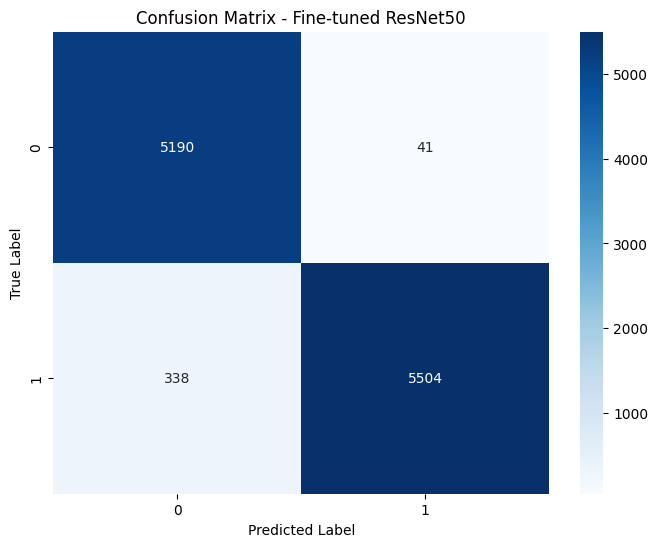

In [27]:
evaluate_model(model_resnet, test_generator, "Fine-tuned ResNet50")

In [28]:
model.save(r"D:\OU\graduation-project\smart-social-network\ai-service\app\data\models\resnet50_finetuned_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


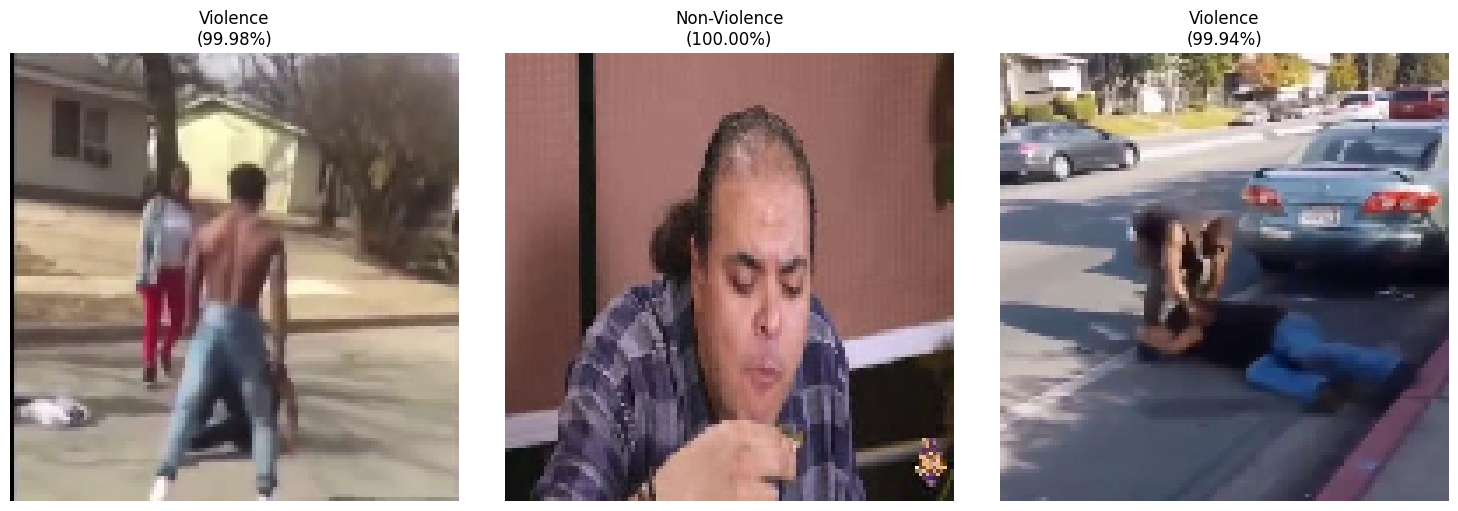

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model


model = load_model(r"D:\OU\graduation-project\smart-social-network\ai-service\app\data\models\resnet50_finetuned_model.h5")

image_paths = [
    os.path.join(base_dir, "violence", "1.jpg"),
    os.path.join(base_dir, "non_violence", "102.jpg"),
    os.path.join(base_dir, "violence", "100.jpg")
]


plt.figure(figsize=(15, 5))

for idx, img_path in enumerate(image_paths):
    
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # Make prediction
    prediction = model.predict(img_array)[0][0]
    label = "Violence" if prediction >= 0.5 else "Non-Violence"
    confidence = prediction * 100 if prediction >= 0.5 else (1 - prediction) * 100

    # Plot image and prediction
    plt.subplot(1, 3, idx + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label}\n({confidence:.2f}%)")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


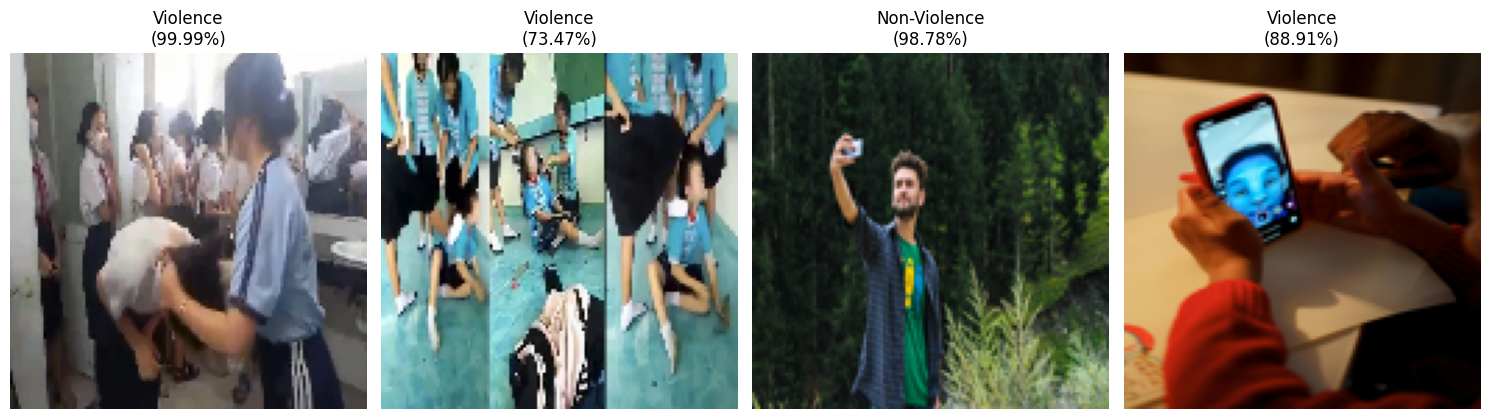

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from PIL import Image
import requests
from io import BytesIO

model = load_model(r"D:\OU\graduation-project\smart-social-network\ai-service\app\data\models\resnet50_finetuned_model.h5")

image_paths = [
    r"D:\OU\graduation-project\images_post\violence\violence001.webp",
    r"D:\OU\graduation-project\images_post\violence\violence002.webp",
    "https://res.cloudinary.com/dohsfqs6d/image/upload/v1756880309/posts/IMAGE/mj4mt20lfmxqixxypezm.jpg",
    "https://res.cloudinary.com/dohsfqs6d/image/upload/v1756918888/posts/IMAGE/ta8lgm4cwdkw99tyzzsa.jpg"
]

plt.figure(figsize=(15, 5))

for idx, img_path in enumerate(image_paths):
    # Nếu là URL, tải ảnh bằng requests + PIL
    if img_path.startswith("http"):
        response = requests.get(img_path)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize((128, 128))
    else:
        img = image.load_img(img_path, target_size=(128, 128))
    
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # normalize

    # Dự đoán
    prediction = model.predict(img_array)[0][0]
    label = "Violence" if prediction >= 0.5 else "Non-Violence"
    confidence = prediction * 100 if prediction >= 0.5 else (1 - prediction) * 100

    plt.subplot(1, 4, idx + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label}\n({confidence:.2f}%)")

plt.tight_layout()
plt.show()
